In [ ]:
# ============================================================
# MODULE 1: EDA + ML Prediction
# Telecom Customer Intelligence System
# ============================================================

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

In [3]:
sns.set_theme(style='whitegrid', palette='muted')
print("All libraries loaded successfully.")

All libraries loaded successfully.


In [4]:
# ── Load & Inspect Data ──────────────────────────────
df = pd.read_csv(r"C:\Users\sonalmar\OneDrive - AMDOCS\Documents\telecom-churn-intelligence\telecom_churn_data.csv")


In [28]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Shape: (1000, 20)

Data Types:
 customer_id              object
age                       int64
gender                   object
tenure_months             int64
contract_type            object
internet_service         object
tech_support             object
online_security          object
payment_method           object
monthly_charges         float64
total_charges           float64
num_products              int64
data_usage_gb           float64
avg_call_duration       float64
network_issues_count      int64
num_complaints            int64
late_payments             int64
complaint_text           object
sentiment_label          object
churn                     int64
dtype: object


In [29]:
print("\nNull Values:\n", df.isnull().sum())



Null Values:
 customer_id             0
age                     0
gender                  0
tenure_months           0
contract_type           0
internet_service        0
tech_support            0
online_security         0
payment_method          0
monthly_charges         0
total_charges           0
num_products            0
data_usage_gb           0
avg_call_duration       0
network_issues_count    0
num_complaints          0
late_payments           0
complaint_text          0
sentiment_label         0
churn                   0
dtype: int64


In [30]:
print("\nChurn Distribution:\n", df['churn'].value_counts())


Churn Distribution:
 churn
0    556
1    444
Name: count, dtype: int64


In [33]:
print(f"\nChurn Rate: {df['churn'].mean()}")


Churn Rate: 0.444


In [36]:
print("\nBasic Stats:\n", df.describe().round(2))


Basic Stats:
            age  tenure_months  monthly_charges  total_charges  num_products  \
count  1000.00        1000.00          1000.00        1000.00       1000.00   
mean     43.12          35.49          1388.41       45852.11          3.02   
std      12.33          20.71           630.32       35711.60          1.42   
min      22.00           1.00           301.44         308.63          1.00   
25%      32.75          17.00           831.36       16562.66          2.00   
50%      43.00          35.00          1378.79       36618.56          3.00   
75%      54.00          54.00          1946.10       68761.74          4.00   
max      64.00          71.00          2499.03      154687.24          5.00   

       data_usage_gb  avg_call_duration  network_issues_count  num_complaints  \
count        1000.00            1000.00               1000.00         1000.00   
mean           25.53              13.10                  4.43            3.50   
std            14.44          

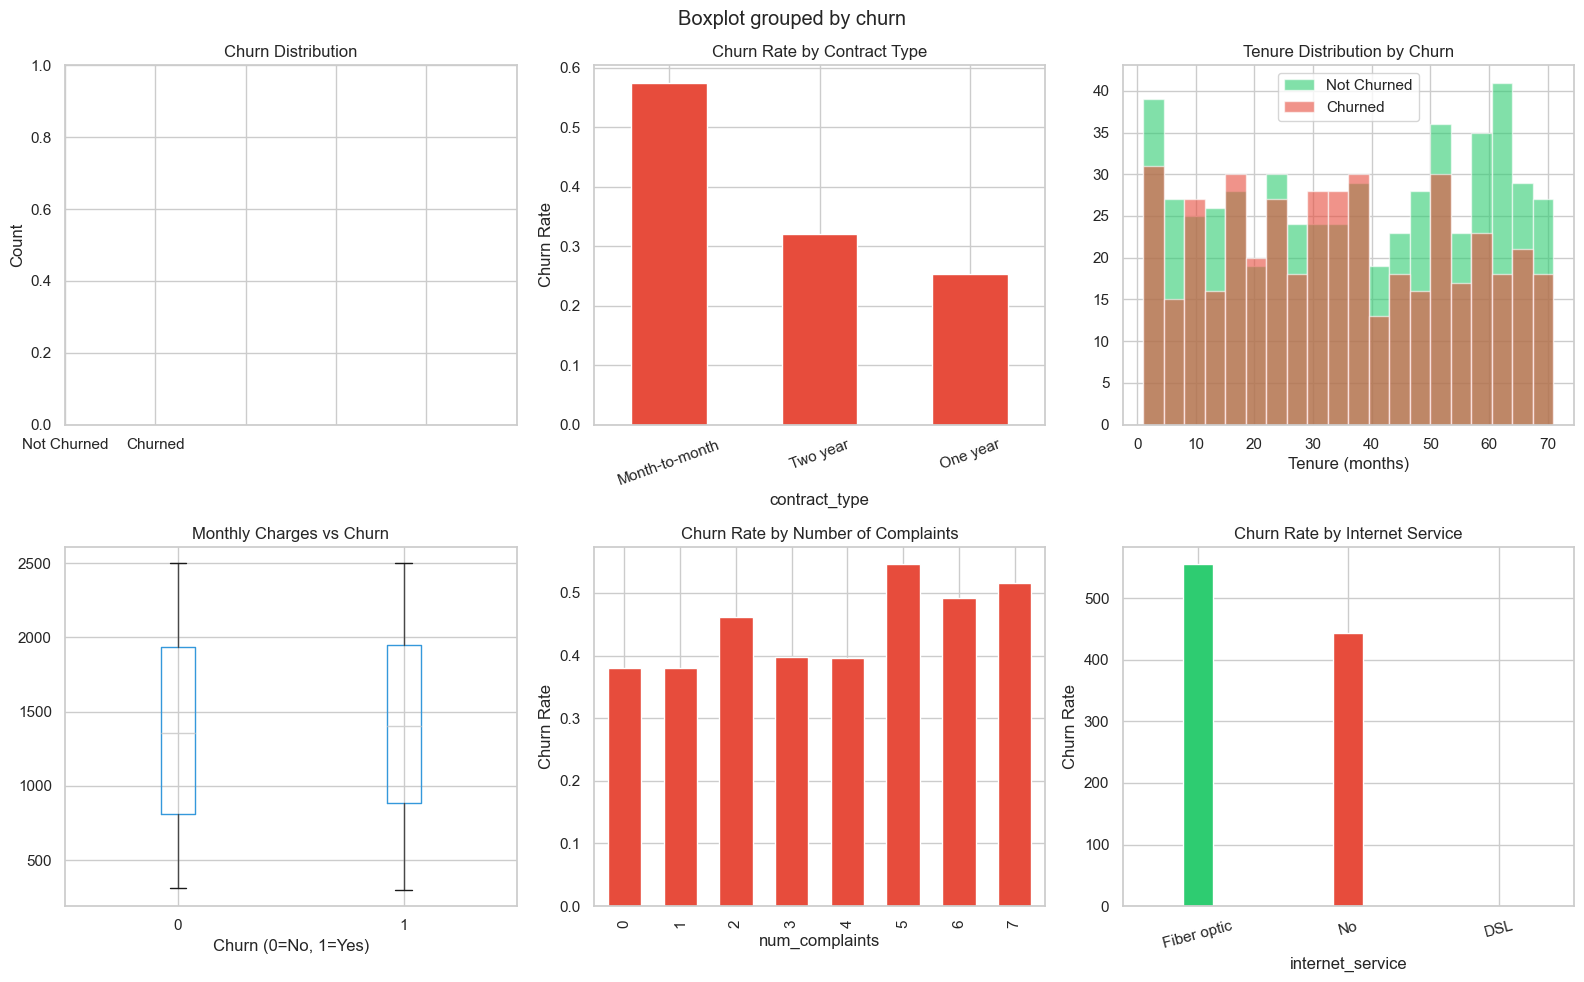

In [94]:
# ── EDA - Univariate Analysis ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Telecom Churn - Key Feature Distributions', fontsize=16, fontweight='bold')

df['churn'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'],
                                 edgecolor='white', width=0.2)
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xticklabels(['Not Churned', 'Churned'], rotation=0)
axes[0,0].set_ylabel('Count')

# Contract type vs churn
ct_churn = df.groupby('contract_type')['churn'].mean().sort_values(ascending=False)
ct_churn.plot(kind='bar', ax=axes[0,1], color='#e74c3c', edgecolor='white', width=0.5)
axes[0,1].set_title('Churn Rate by Contract Type')
axes[0,1].set_ylabel('Churn Rate')
axes[0,1].tick_params(axis='x', rotation=20)
 
# Tenure distribution by churn
df[df['churn']==0]['tenure_months'].hist(ax=axes[0,2], alpha=0.6, color='#2ecc71',
                                          bins=20, label='Not Churned')
df[df['churn']==1]['tenure_months'].hist(ax=axes[0,2], alpha=0.6, color='#e74c3c',
                                          bins=20, label='Churned')
axes[0,2].set_title('Tenure Distribution by Churn')
axes[0,2].set_xlabel('Tenure (months)')
axes[0,2].legend()
 
# Monthly charges by churn
df.boxplot(column='monthly_charges', by='churn', ax=axes[1,0],
           boxprops=dict(color='#3498db'))
axes[1,0].set_title('Monthly Charges vs Churn')
axes[1,0].set_xlabel('Churn (0=No, 1=Yes)')
 
# Complaints vs churn
comp_churn = df.groupby('num_complaints')['churn'].mean()
comp_churn.plot(kind='bar', ax=axes[1,1], color='#e74c3c', edgecolor='white', width=0.6)
axes[1,1].set_title('Churn Rate by Number of Complaints')
axes[1,1].set_ylabel('Churn Rate')
 
# Internet service vs churn
is_churn = df.groupby('internet_service')['churn'].mean().sort_values(ascending=False)
is_churn.plot(kind='bar', ax=axes[1,2], color='#9b59b6', edgecolor='white', width=0.5)
axes[1,2].set_title('Churn Rate by Internet Service')
axes[1,2].set_ylabel('Churn Rate')
axes[1,2].tick_params(axis='x', rotation=15)
 
plt.tight_layout()
plt.savefig('outputs/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


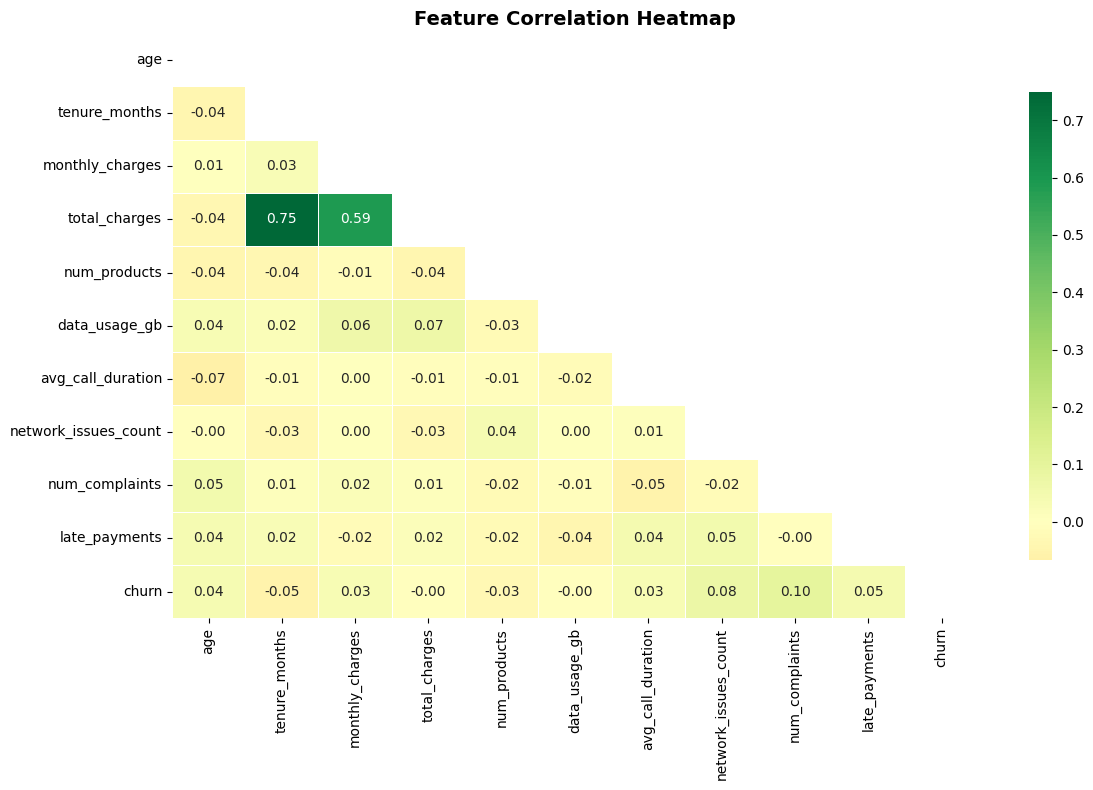

In [29]:
# ── Correlation Heatmap ──────────────────────────────
numeric_cols = ['age','tenure_months','monthly_charges','total_charges',
                'num_products','data_usage_gb','avg_call_duration',
                'network_issues_count','num_complaints','late_payments','churn']
 
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [7]:
# ── Feature Engineering ──────────────────────────────
df_model = df.copy()

In [8]:
le = LabelEncoder()
cat_cols = ['gender','contract_type','internet_service',
            'tech_support','online_security','payment_method']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

In [9]:
df_model['charges_per_month_per_product'] = (df_model['monthly_charges'] /
                                               df_model['num_products'])

In [10]:
df_model['complaint_rate'] = (df_model['num_complaints'] /
                               (df_model['tenure_months'] + 1))

In [11]:
df_model['issue_to_usage_ratio'] = (df_model['network_issues_count'] /
                                     (df_model['data_usage_gb'] + 1))

In [12]:
df_model['is_high_risk_contract'] = (df_model['contract_type'] == 0).astype(int)

In [13]:
feature_cols = [c for c in df_model.columns
                if c not in ['customer_id','churn','complaint_text','sentiment_label']]

In [14]:
X = df_model[feature_cols]
y = df_model['churn']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [17]:
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 800 | Test size: 200


In [18]:
print(f"Features: {len(feature_cols)}")

Features: 20


In [19]:
print("Engineered features added:", 
      ['charges_per_month_per_product','complaint_rate',
       'issue_to_usage_ratio','is_high_risk_contract'])

Engineered features added: ['charges_per_month_per_product', 'complaint_rate', 'issue_to_usage_ratio', 'is_high_risk_contract']


In [20]:
# ── Train Multiple Models ────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=500),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42,
                                                   class_weight='balanced'),
    'XGBoost':             XGBClassifier(n_estimators=200, random_state=42,
                                          use_label_encoder=False, eval_metric='logloss',
                                          scale_pos_weight=1.2)
}

In [21]:
models

{'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
 'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200,
                        random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=200, n_jobs=None,
               num_parallel_tree=None, ..

In [22]:
results = {}

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [24]:
for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='roc_auc')
    model.fit(X_tr, y_train)
    X_te = X_test_sc if name == 'Logistic Regression' else X_test
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'auc': auc, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()
    }

In [26]:
print(f"  {name}")

  XGBoost


In [27]:
print(f"  CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

  CV AUC: 0.6042 ± 0.0405


In [28]:
print(f"  Test AUC: {auc:.4f}")

  Test AUC: 0.6011


In [29]:
print(f"\n{classification_report(y_test, y_pred, target_names=['No Churn','Churn'])}")


              precision    recall  f1-score   support

    No Churn       0.59      0.59      0.59       111
       Churn       0.49      0.49      0.49        89

    accuracy                           0.55       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.55      0.55      0.55       200



Text(0, 0.5, 'True Positive Rate')

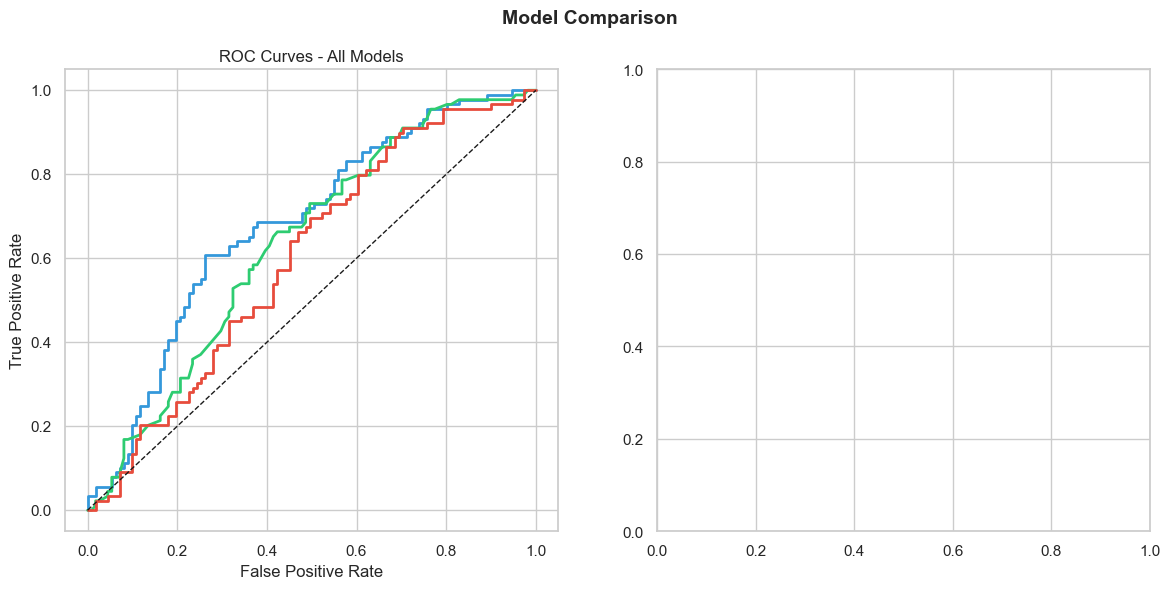

In [89]:
# ── Model Comparison + ROC Curves ────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')
colors = ['#3498db','#2ecc71','#e74c3c']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, lw=2)
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[0].set_title('ROC Curves - All Models')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')


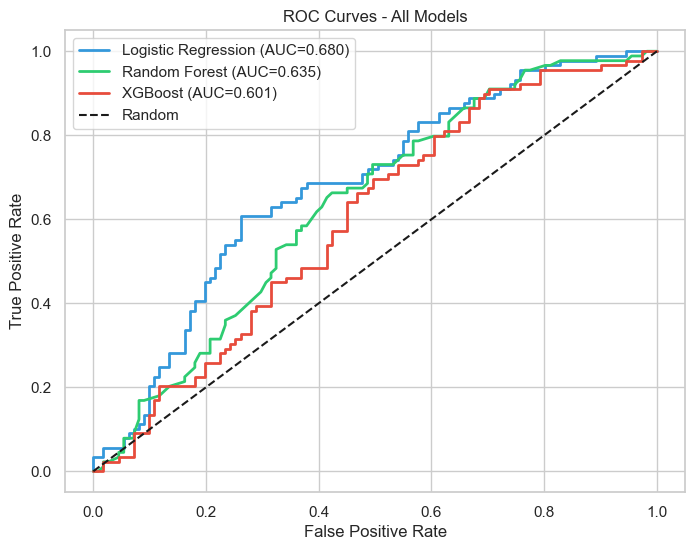

In [38]:
# AUC bar comparison

from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, lw=2)

ax.plot([0,1], [0,1], 'k--', label='Random')
ax.set_title('ROC Curves - All Models')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()

plt.show()

Best model: Logistic Regression  |  AUC: 0.6804


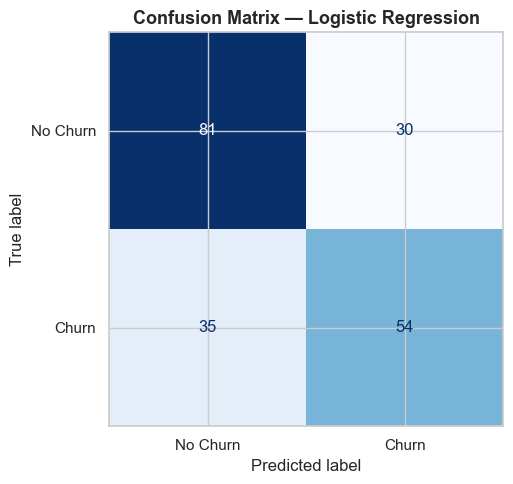

In [39]:
# ──  Best Model - Confusion Matrix ────────────────────
best_name = max(results, key=lambda k: results[k]['auc'])
best = results[best_name]
print(f"Best model: {best_name}  |  AUC: {best['auc']:.4f}")
 
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
 

Computing SHAP values (this may take ~30 seconds)...


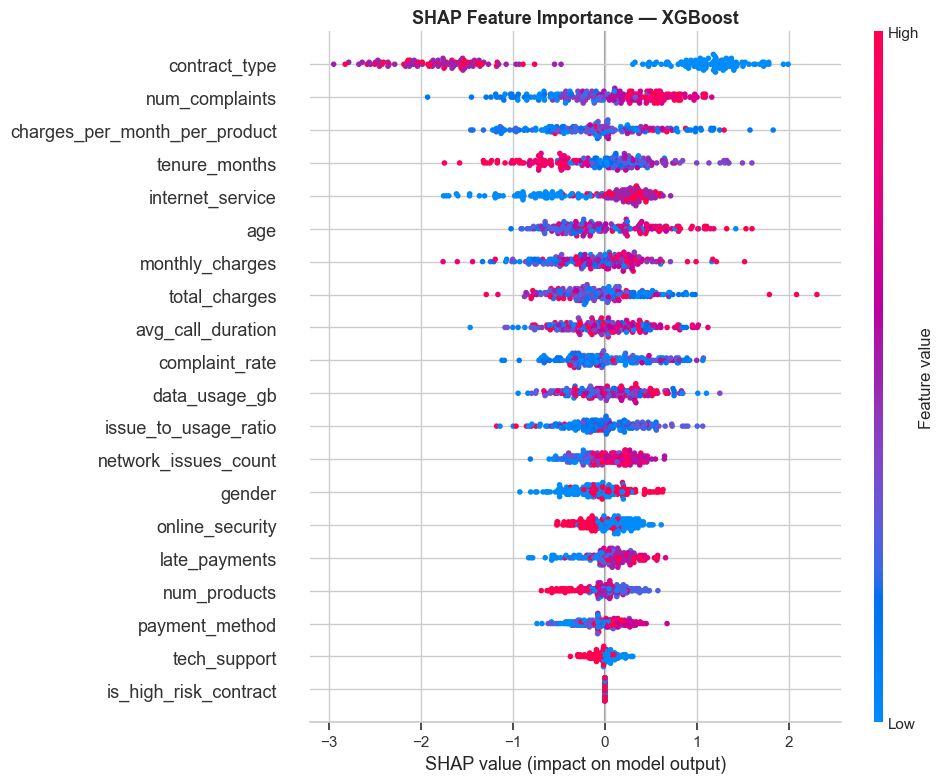

In [40]:
# ── SHAP Explainability ──────────────────────────────
print("Computing SHAP values (this may take ~30 seconds)...")
 
best_model = results['XGBoost']['model']
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
 
# SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                  show=False, plot_size=(10, 8))
plt.title('SHAP Feature Importance — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Top feature importances for Power BI
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)
 
feature_importance_df.to_csv('outputs/feature_importance.csv', index=False)
print("\nTop 10 features:")
print(feature_importance_df.head(10).to_string(index=False))


Top 10 features:
                      feature  importance
                contract_type    0.156601
                 num_products    0.063034
             internet_service    0.059438
               num_complaints    0.054223
            avg_call_duration    0.054173
                tenure_months    0.052630
charges_per_month_per_product    0.052390
                total_charges    0.052139
                          age    0.051766
               payment_method    0.048592


In [42]:
# ── Save predictions for Power BI ───────────────────
X_test_copy = X_test.copy()
X_test_copy['customer_id'] = df.iloc[y_test.index]['customer_id'].values
X_test_copy['actual_churn'] = y_test.values
X_test_copy['predicted_churn'] = best['y_pred']
X_test_copy['churn_probability'] = best['y_prob'].round(4)
X_test_copy['risk_segment'] = pd.cut(best['y_prob'],
                                      bins=[0, 0.3, 0.6, 1.0],
                                      labels=['Low Risk','Medium Risk','High Risk'])

In [44]:
# Add back raw features for dashboard
raw_cols = ['contract_type','internet_service','tenure_months',
            'monthly_charges','num_complaints']
for col in raw_cols:
    X_test_copy[col+'_raw'] = df.iloc[y_test.index][col].values
 
X_test_copy.to_csv('outputs/predictions_for_powerbi.csv', index=False)
print(f"\nPredictions saved: {X_test_copy.shape[0]} rows")
print("Risk segment distribution:\n",
      X_test_copy['risk_segment'].value_counts())

 


Predictions saved: 200 rows
Risk segment distribution:
 risk_segment
Medium Risk    91
Low Risk       60
High Risk      49
Name: count, dtype: int64


In [52]:
# NLP libraries

!pip install nltk
!pip install transformers
!pip install torch torchvision torchaudio
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
 
# Deep Learning / Transformers
from transformers import pipeline, AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
 
import warnings
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.5/114.6 MB 21.0 MB/s eta 0:00:06
   ---------------------------------------- 0.8/114.6 MB 2.1 MB/s eta 0:00:55
    --------------------------------------- 1.6/114.6 MB 2.2 MB/s eta 0:00:51
    --------------------------------------- 1.8/114.6 MB 2.6 MB/s eta 0:00:44
    --------------------------------------- 2.6/114.6 MB 2.3 MB/s eta 0:00:49
   - -------------------------------------- 3.9/114.6 MB 3.0 MB/s eta 0:00:37
   - -------------------------------------- 4.2/114.6 MB 3.1 MB/s eta 0:00:36
   - -------------------------------------- 5.2/114.6 MB 3.2 MB/s eta 0:00:35
   - -------------------------------------- 5.2/114.6 MB 3.2 MB/s eta 0:00:35
   -- ------------------------------------- 6.6/114.6 MB 3.1 MB/s eta 0:00:35
   -- ------------------------------------- 6.6/114.6 MB 3.1 MB/s eta 0:00:35
   -- ------------------------------------- 8.1/114.6 MB 3.2 MB/s eta 


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:

from collections import Counter
import re
 
# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
 

In [66]:
from transformers import pipeline, AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
 
import warnings
warnings.filterwarnings('ignore')

In [67]:
for pkg in ['punkt','stopwords','wordnet','averaged_perceptron_tagger']:
    nltk.download(pkg, quiet=True)
 
print("All NLP libraries loaded.")

All NLP libraries loaded.


In [69]:
# ── Load Data ─────────────────────────────────────────
df = pd.read_csv(r"C:\Users\sonalmar\OneDrive - AMDOCS\Documents\telecom-churn-intelligence\telecom_churn_data.csv")

print(f"Dataset: {df.shape}")
print(f"\nSentiment distribution:\n{df['sentiment_label'].value_counts()}")
print(f"\nSample complaints:\n{df['complaint_text'].head(5).to_string()}")
 

Dataset: (1000, 20)

Sentiment distribution:
sentiment_label
Negative    534
Neutral     466
Name: count, dtype: int64

Sample complaints:
0    When will the new 5G network be available in m...
1    How do I add an international calling pack to ...
2    Charged extra on my bill without any prior not...
3    Promised a discount during signup but it was n...
4    Called support five times but issue is still n...


In [71]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # required for Python 3.8+
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sonalmar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sonalmar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sonalmar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sonalmar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sonalmar\AppData\Roaming\nltk_data...


True

In [72]:
# ──  Text Preprocessing ───────────────────────────────
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['complaint_text'].apply(preprocess_text)
 

In [73]:
print("Sample original vs cleaned:")
for i in range(3):
    print(f"\nOriginal: {df['complaint_text'].iloc[i]}")
    print(f"Cleaned:  {df['clean_text'].iloc[i]}")

Sample original vs cleaned:

Original: When will the new 5G network be available in my area
Cleaned:  new network available area

Original: How do I add an international calling pack to my account
Cleaned:  add international calling pack account

Original: Charged extra on my bill without any prior notice or explanation
Cleaned:  charged extra bill without prior notice explanation


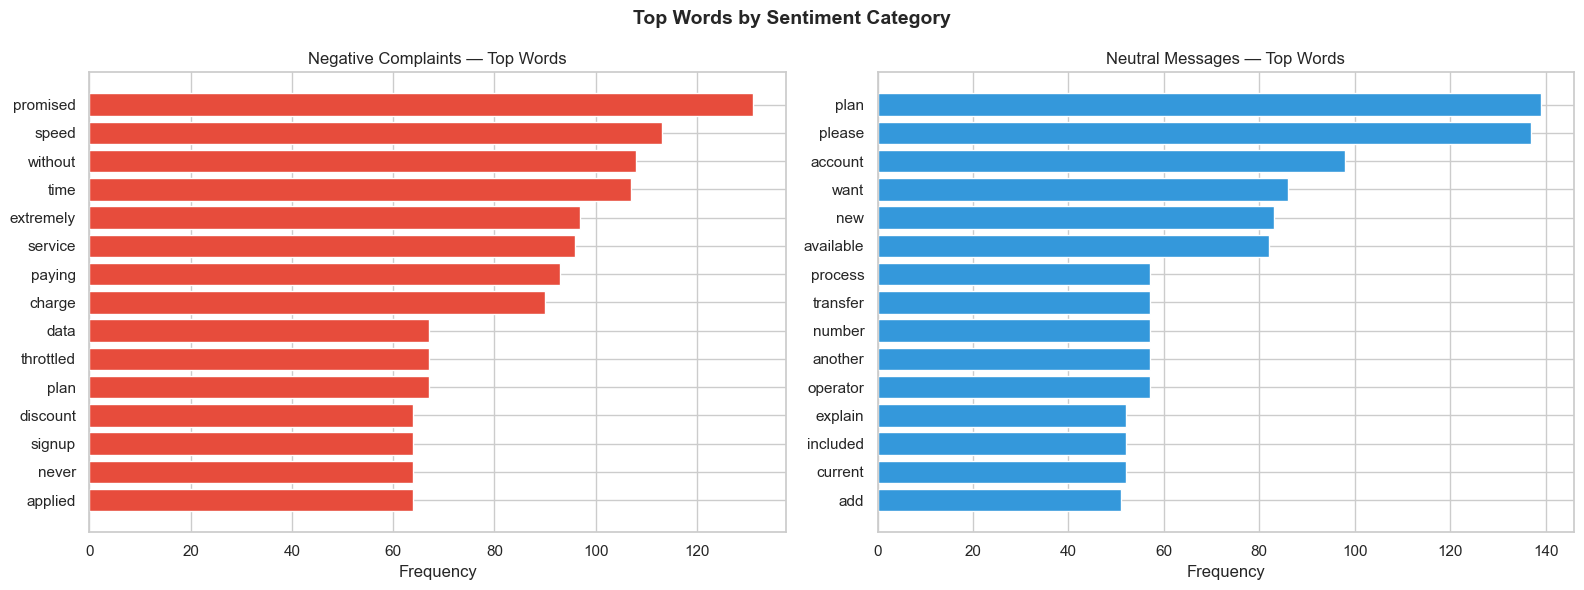

In [96]:
# ── TF-IDF Analysis + Word Frequency ─────────────────
# Word frequency by sentiment
neg_text = ' '.join(df[df['sentiment_label']=='Negative']['clean_text'])
neu_text = ' '.join(df[df['sentiment_label']=='Neutral']['clean_text'])
 
neg_words = Counter(neg_text.split()).most_common(15)
neu_words = Counter(neu_text.split()).most_common(15)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top Words by Sentiment Category', fontsize=14, fontweight='bold')
 
words_neg, counts_neg = zip(*neg_words)
axes[0].barh(words_neg, counts_neg, color='#e74c3c', edgecolor='white')
axes[0].set_title('Negative Complaints — Top Words')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()
 
words_neu, counts_neu = zip(*neu_words)
axes[1].barh(words_neu, counts_neu, color='#3498db', edgecolor='white')
axes[1].set_title('Neutral Messages — Top Words')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()
 
plt.tight_layout()
plt.savefig('outputs/nlp_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
 



TF-IDF + Logistic Regression — Sentiment Classification
Accuracy: 1.0000
              precision    recall  f1-score   support

     Neutral       1.00      1.00      1.00        94
    Negative       1.00      1.00      1.00       106

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



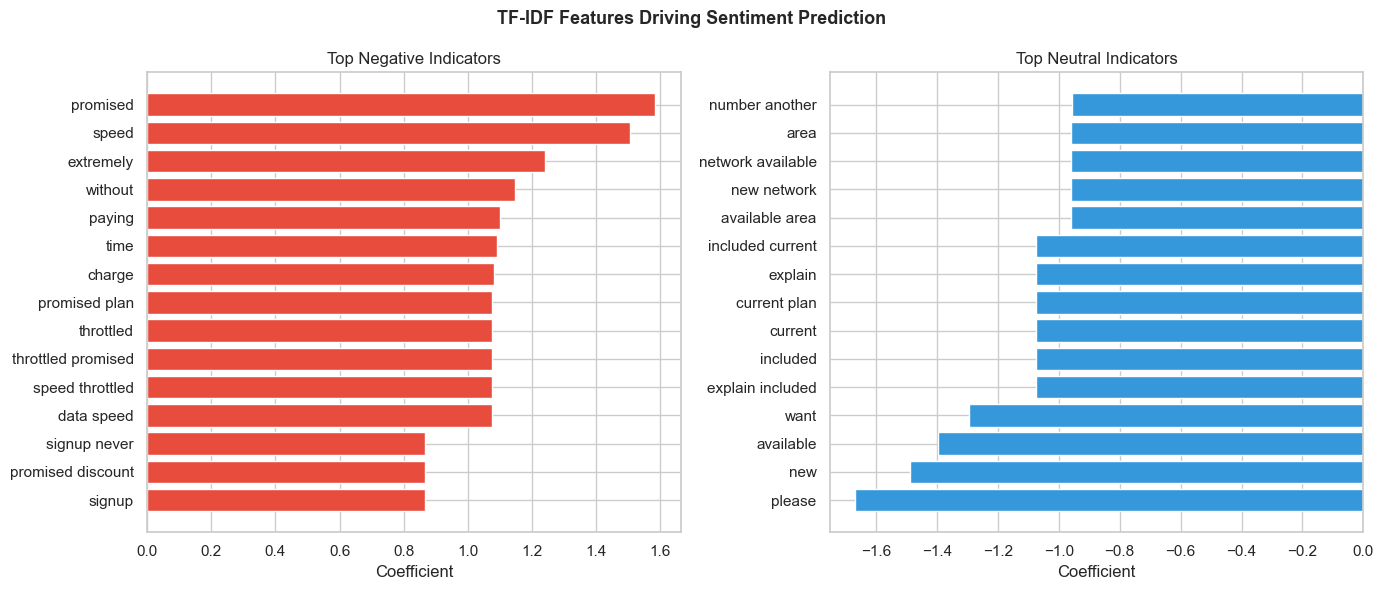

In [97]:
# ── TF-IDF Sentiment Classifier ──────────────────────
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2), min_df=2)
X_tfidf = tfidf.fit_transform(df['clean_text'])
y_sent = (df['sentiment_label'] == 'Negative').astype(int)
 
X_tr, X_te, y_tr, y_te = train_test_split(X_tfidf, y_sent,
                                            test_size=0.2, random_state=42)
lr = LogisticRegression(random_state=42, max_iter=500)
lr.fit(X_tr, y_tr)
y_pred = lr.predict(X_te)
 
print("TF-IDF + Logistic Regression — Sentiment Classification")
print(f"Accuracy: {accuracy_score(y_te, y_pred):.4f}")
print(classification_report(y_te, y_pred,
                              target_names=['Neutral','Negative']))
 
# Top TF-IDF features
feature_names = tfidf.get_feature_names_out()
coef = lr.coef_[0]
top_neg_idx = np.argsort(coef)[-15:]
top_pos_idx = np.argsort(coef)[:15]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('TF-IDF Features Driving Sentiment Prediction', fontsize=13, fontweight='bold')
 
axes[0].barh(feature_names[top_neg_idx], coef[top_neg_idx], color='#e74c3c')
axes[0].set_title('Top Negative Indicators')
axes[0].set_xlabel('Coefficient')
 
axes[1].barh(feature_names[top_pos_idx], coef[top_pos_idx], color='#3498db')
axes[1].set_title('Top Neutral Indicators')
axes[1].set_xlabel('Coefficient')
 
plt.tight_layout()
plt.savefig('outputs/nlp_tfidf_features.png', dpi=150, bbox_inches='tight')
plt.show()
 

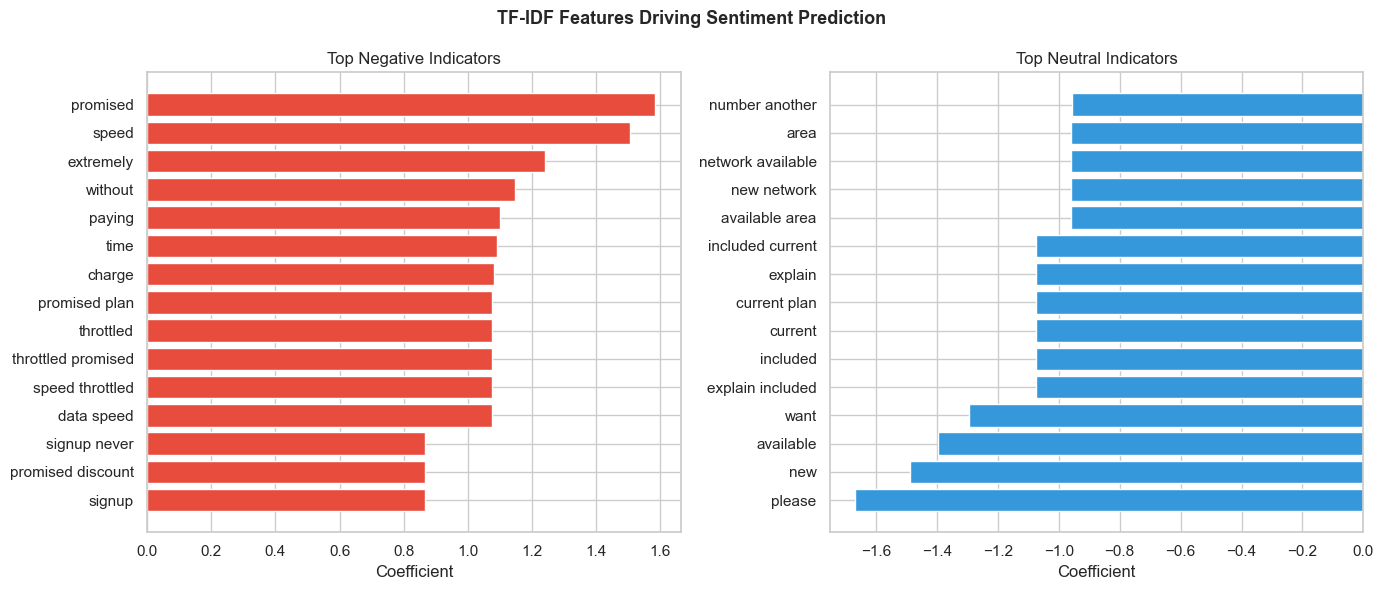

In [79]:
# Top TF-IDF features
feature_names = tfidf.get_feature_names_out()
coef = lr.coef_[0]
top_neg_idx = np.argsort(coef)[-15:]
top_pos_idx = np.argsort(coef)[:15]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('TF-IDF Features Driving Sentiment Prediction', fontsize=13, fontweight='bold')
 
axes[0].barh(feature_names[top_neg_idx], coef[top_neg_idx], color='#e74c3c')
axes[0].set_title('Top Negative Indicators')
axes[0].set_xlabel('Coefficient')
 
axes[1].barh(feature_names[top_pos_idx], coef[top_pos_idx], color='#3498db')
axes[1].set_title('Top Neutral Indicators')
axes[1].set_xlabel('Coefficient')
 
plt.tight_layout()
plt.savefig('outputs/nlp_tfidf_features.png', dpi=150, bbox_inches='tight')
plt.show()


Running LDA Topic Modelling...


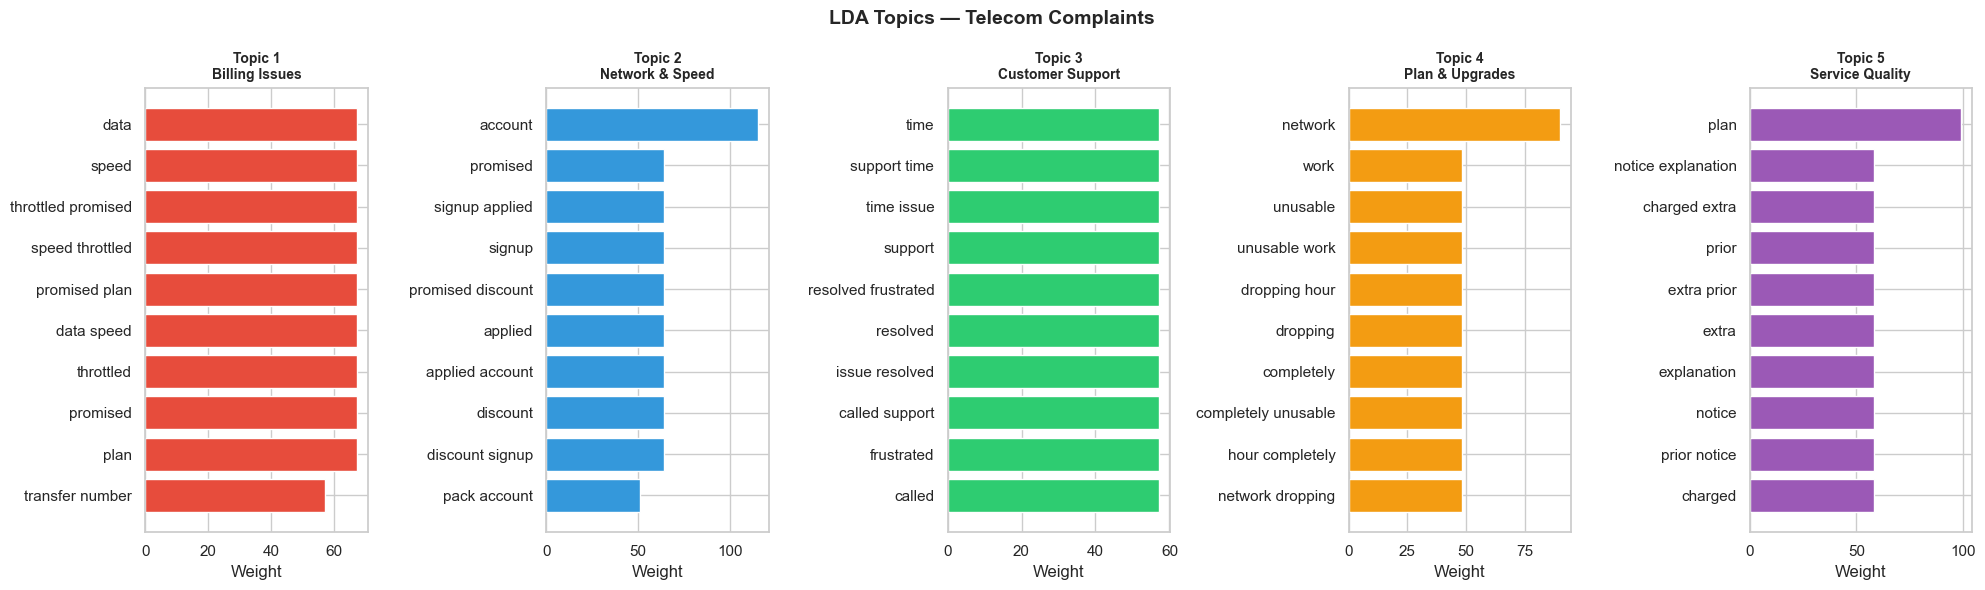

In [99]:
# ── LDA Topic Modelling ──────────────────────────────
print("\nRunning LDA Topic Modelling...")
 
count_vec = CountVectorizer(max_features=300, min_df=3,
                             stop_words='english', ngram_range=(1,2))
X_count = count_vec.fit_transform(df['clean_text'])
 
n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42,
                                  max_iter=20, learning_method='batch')
lda.fit(X_count)
 
topic_labels = {
    0: 'Billing Issues',
    1: 'Network & Speed',
    2: 'Customer Support',
    3: 'Plan & Upgrades',
    4: 'Service Quality'
}
 
count_features = count_vec.get_feature_names_out()
 
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle('LDA Topics — Telecom Complaints', fontsize=14, fontweight='bold')
 
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
for topic_idx, (topic, ax) in enumerate(zip(lda.components_, axes)):
    top_words_idx = topic.argsort()[-10:]
    top_words = [count_features[i] for i in top_words_idx]
    top_vals  = [topic[i] for i in top_words_idx]
    ax.barh(top_words, top_vals, color=colors[topic_idx], edgecolor='white')
    ax.set_title(f'Topic {topic_idx+1}\n{topic_labels[topic_idx]}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Weight')
 
plt.tight_layout()
plt.savefig('outputs/nlp_topics.png', dpi=150, bbox_inches='tight')
plt.show()
 

 


In [100]:
# Assign dominant topic to each row
doc_topics = lda.transform(X_count)
df['dominant_topic'] = doc_topics.argmax(axis=1)
df['topic_label'] = df['dominant_topic'].map(topic_labels)
 

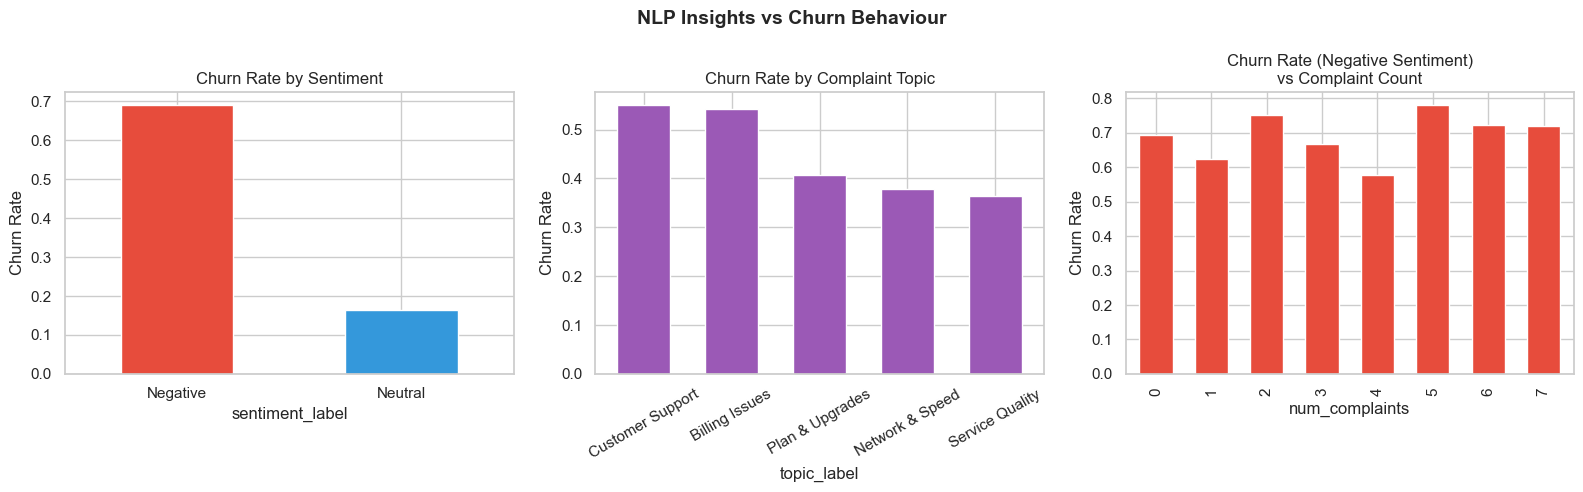

In [101]:
# ── Sentiment vs Churn Analysis ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('NLP Insights vs Churn Behaviour', fontsize=14, fontweight='bold')
 
# Sentiment vs churn rate
sent_churn = df.groupby('sentiment_label')['churn'].mean()
sent_churn.plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db'],
                edgecolor='white', width=0.5)
axes[0].set_title('Churn Rate by Sentiment')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=0)
 
# Topic vs churn rate
topic_churn = df.groupby('topic_label')['churn'].mean().sort_values(ascending=False)
topic_churn.plot(kind='bar', ax=axes[1], color='#9b59b6', edgecolor='white', width=0.6)
axes[1].set_title('Churn Rate by Complaint Topic')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(axis='x', rotation=30)
 
# Complaint count vs churn for negative sentiment
neg_df = df[df['sentiment_label']=='Negative']
neg_churn = neg_df.groupby('num_complaints')['churn'].mean()
neg_churn.plot(kind='bar', ax=axes[2], color='#e74c3c', edgecolor='white', width=0.6)
axes[2].set_title('Churn Rate (Negative Sentiment)\nvs Complaint Count')
axes[2].set_ylabel('Churn Rate')
 
plt.tight_layout()
plt.savefig('outputs/nlp_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [102]:
# ── CELL 9: Save enriched dataset ────────────────────────────
df.to_csv('outputs/enriched_with_nlp.csv', index=False)
print(f"\nEnriched dataset saved: {df.shape}")
print(f"\nTopic distribution:\n{df['topic_label'].value_counts()}")

 


Enriched dataset saved: (1000, 23)

Topic distribution:
topic_label
Service Quality     244
Plan & Upgrades     223
Billing Issues      221
Network & Speed     161
Customer Support    151
Name: count, dtype: int64
